In [119]:
import sys
import os

src_path = os.path.abspath(os.path.join("..", "..", "src"))
sys.path.append(src_path)

In [120]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt
import spikeinterface.extractors as se
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np
from plotting import rsp_plot

path = r'C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\TestData\20250414_102411_3_20_sprite_merged.rec'
# stream id’s → ecu - resp, trodes - heart and neural data

In [121]:
rec = se.read_spikegadgets(path, stream_id='trodes')
print(rec)

SpikeGadgetsRecordingExtractor: 32 channels - 20.0kHz - 1 segments - 2,380,676 samples 
                                119.03s (1.98 minutes) - int16 dtype - 145.30 MiB
  file_path: C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\TestData\20250414_102411_3_20_sprite_merged.rec


In [122]:
# Sampling frequency (Hz)
fs = rec.get_sampling_frequency()
print("Sampling frequency:", fs)

# Number of channels
n_channels = rec.get_num_channels()
print("Number of channels:", n_channels)

# Channel IDs (usually integers)
channel_ids = rec.get_channel_ids()
print("Channel IDs:", channel_ids)

# Total number of samples (frames)
n_samples = rec.get_num_frames()
print("Number of samples (frames):", n_samples)

# Duration in seconds
duration_sec = n_samples / fs
print("Duration (seconds):", duration_sec)

Sampling frequency: 20000.0
Number of channels: 32
Channel IDs: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15'
 '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29'
 '30' '31']
Number of samples (frames): 2380676
Duration (seconds): 119.0338


In [123]:
ekg_signal = rec.get_traces(channel_ids=['21']).squeeze()

# print shape and first 10 values
print("Shape of ch21 data:", ekg_signal.shape)
print("First 10 values of ch21 data:", ekg_signal[:10])

Shape of ch21 data: (2380676,)
First 10 values of ch21 data: [ 904  911 1075 1335 1567 1575 1611 1559 1551 1623]


In [124]:
neuro_df = pd.DataFrame({"ECG": ekg_signal})

signals, info = nk.ecg_process(neuro_df["ECG"], sampling_rate=fs)

In [125]:
res = nk.ecg_analyze(signals, sampling_rate=fs)

c:\Users\thoma\miniconda3\envs\spikeenv\lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


In [126]:
res.head()

,ECG_Rate_Mean,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,62.918083,[[1004.5650862068966]],[[519.4497989813179]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[nan]],[[640.6425500332018]],...,[[1.945910149055313]],[[6.806256857196536]],[[1.5481432488349707]],[[1.320487543793624]],[[1.5892252529618816]],[[2.1530762646662542]],[[1.9546518371890105]],[[1.9878302482801844]],[[3.787908347247624]],[[1.0641694647611748]]


In [127]:
ekg_df = rsp_plot.Rsp_Kit(
    resp_data= ekg_signal,
    fs=fs,
    size=n_samples,
    start_time=0,
    end_time=None,
)

### Plots No Filtering

C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\plotting\rsp_plot.py:333: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.3)


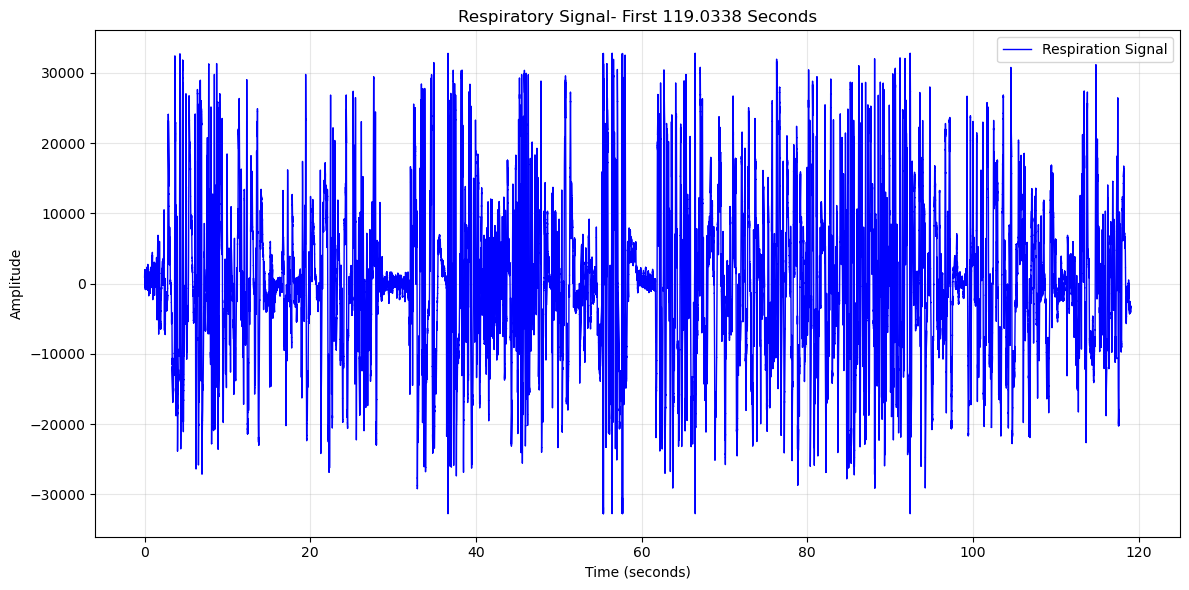

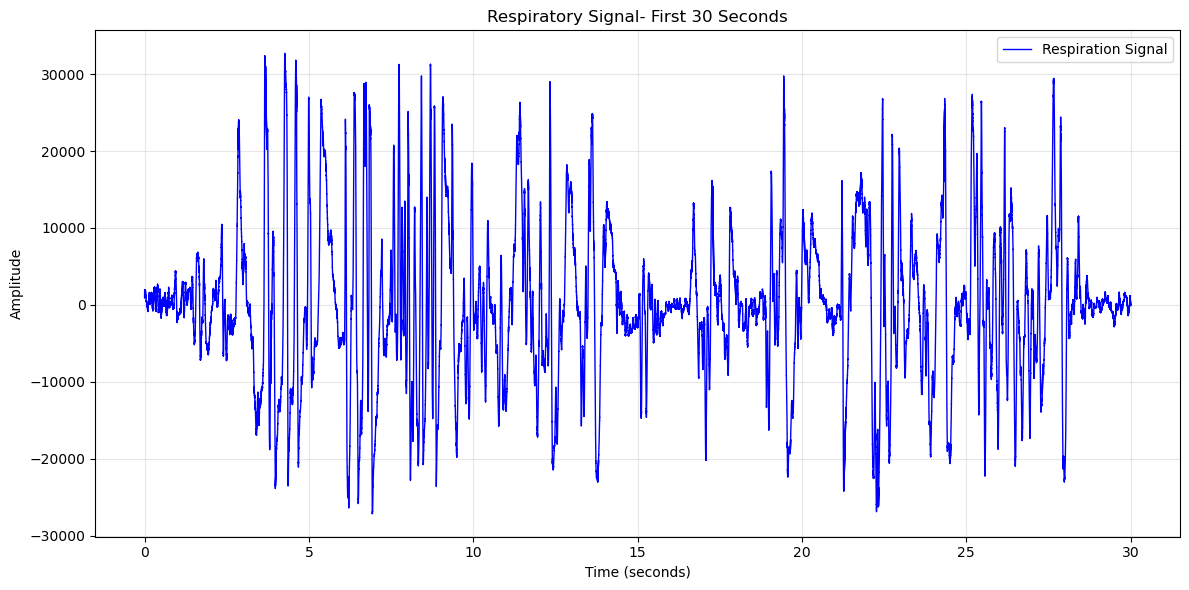

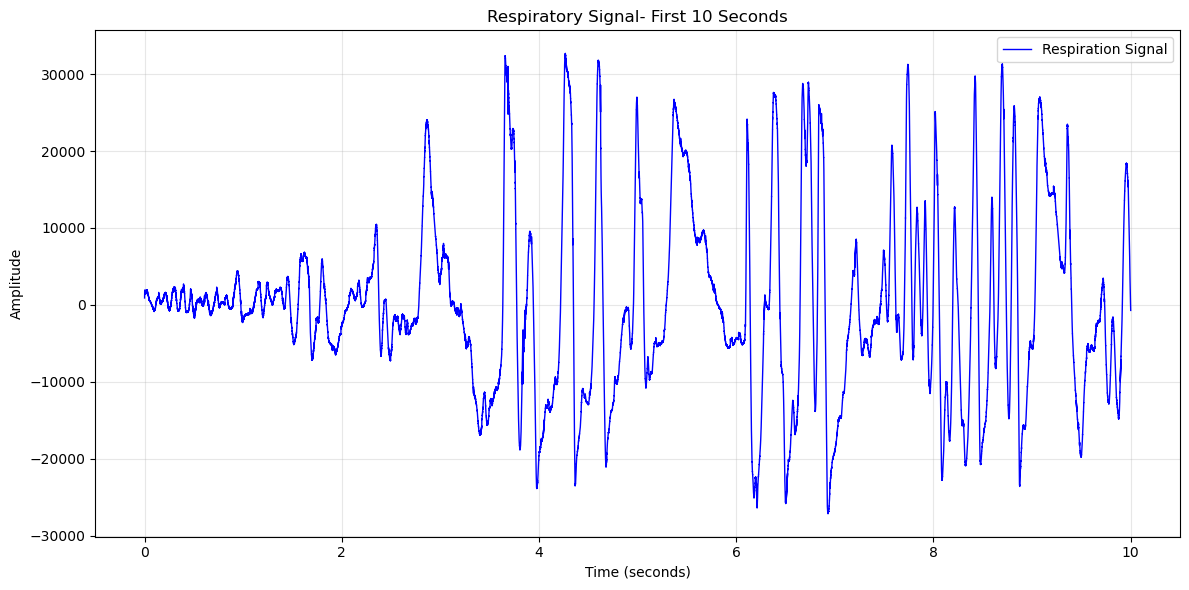

In [128]:
ekg_df.plot(duration=n_samples / fs)
ekg_df.plot(duration=30)  # Plot for 10 seconds
ekg_df.plot()

In [129]:
nk.signal_flatline(ekg_signal)

0.9836890866291759

In [130]:
np.percentile(np.abs(np.diff(ekg_signal)), [1, 50, 99])


array([  0.,  16., 103.])

In [131]:
'''
def detect_signal_loss(signal, threshold=0.0001, window_ms=100, sampling_rate=1000):
    """
    Detect flatline signal regions in raw ECG using a sliding window.

    Args:
        signal (np.array): Raw 1D ECG signal.
        threshold (float): Smallest allowable point-to-point change.
        window_ms (float): Duration of window to consider for flatness (ms).
        sampling_rate (int): Sampling rate in Hz.

    Returns:
        np.array: Boolean array where True indicates loss.
    """
    window = int((window_ms / 1000) * sampling_rate)
    diffs = np.abs(np.diff(signal, prepend=signal[0]))
    flat = diffs < threshold
    loss_mask = np.convolve(flat, np.ones(window, dtype=int), mode='same') >= window
    return loss_mask
'''

'\ndef detect_signal_loss(signal, threshold=0.0001, window_ms=100, sampling_rate=1000):\n    """\n    Detect flatline signal regions in raw ECG using a sliding window.\n\n    Args:\n        signal (np.array): Raw 1D ECG signal.\n        threshold (float): Smallest allowable point-to-point change.\n        window_ms (float): Duration of window to consider for flatness (ms).\n        sampling_rate (int): Sampling rate in Hz.\n\n    Returns:\n        np.array: Boolean array where True indicates loss.\n    """\n    window = int((window_ms / 1000) * sampling_rate)\n    diffs = np.abs(np.diff(signal, prepend=signal[0]))\n    flat = diffs < threshold\n    loss_mask = np.convolve(flat, np.ones(window, dtype=int), mode=\'same\') >= window\n    return loss_mask\n'

In [132]:
'''
def detect_signal_loss(signal, threshold=.01, window=500):
    """
    Detect flatline signal regions using a sliding window.
    
    Args:
        signal (np.array): 1D array of signal values.
        threshold (float): Smallest allowable change between consecutive points.
        window (int): Number of samples over which to check for flatness.
    
    Returns:
        np.array: Boolean array where True means the signal is considered "lost".
    """
    diffs = np.abs(np.diff(signal, prepend=signal[0]))  # prepend to preserve size
    flat = diffs < threshold # if the difference between consecutive points is less than threshold
    # of loss in 
    loss_mask = np.convolve(flat, np.ones(window), mode='same') >= window # convolve - counts # of trues in sliding windo | >= window - checks if # of trues in sliding window are >= window size 

    return loss_mask

'''

'\ndef detect_signal_loss(signal, threshold=.01, window=500):\n    """\n    Detect flatline signal regions using a sliding window.\n    \n    Args:\n        signal (np.array): 1D array of signal values.\n        threshold (float): Smallest allowable change between consecutive points.\n        window (int): Number of samples over which to check for flatness.\n    \n    Returns:\n        np.array: Boolean array where True means the signal is considered "lost".\n    """\n    diffs = np.abs(np.diff(signal, prepend=signal[0]))  # prepend to preserve size\n    flat = diffs < threshold # if the difference between consecutive points is less than threshold\n    # of loss in \n    loss_mask = np.convolve(flat, np.ones(window), mode=\'same\') >= window # convolve - counts # of trues in sliding windo | >= window - checks if # of trues in sliding window are >= window size \n\n    return loss_mask\n\n'

In [133]:
def detect_signal_loss_variance(signal, window_ms=300, sampling_rate=1000, var_threshold=1.0):
    """
    Detect signal loss based on low variance in a sliding window.

    Args:
        signal (np.array): Raw ECG signal.
        window_ms (int): Window size in milliseconds.
        sampling_rate (int): Sampling rate in Hz.
        var_threshold (float): Variance threshold below which signal is considered lost.

    Returns:
        np.array: Boolean array where True indicates signal loss.
    """
    window_size = int((window_ms / 1000) * sampling_rate)
    pad = window_size // 2
    padded_signal = np.pad(signal, pad_width=pad, mode='reflect')
    loss_mask = np.zeros_like(signal, dtype=bool)

    for i in range(len(signal)):
        window_segment = padded_signal[i:i + window_size]
        if np.var(window_segment) < var_threshold:
            loss_mask[i] = True

    return loss_mask


In [134]:
loss_signal = detect_signal_loss_variance(ekg_signal)

In [135]:
loss_indices = np.where(loss_signal)[0]
print(len(loss_indices))

0


#### Bandpass Filter - Keeps signal between 10-250 Hz

In [136]:
'''
Bandpass filter: alters frequency content of the signal, removes
low frequency drift and high frequency noise
'''
# NeuroKit2 Butterworth Bandpass Filter
ekg_band = nk.signal_filter(
    ekg_signal,  # Input signal
    lowcut=10,   # Low cutoff frequency (Hz)
    highcut=250,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=fs,  # Sampling rate
    order=2  # Filter order
)
